# MDS individual
20260105 ~ 

### individual:
    1. 何人かピックアップ
        1.1 正定値1名
        1.2 gapあり3名（plateauが20以上、10〜20、0~10）
        1.3 gapなし3名（plateauが20以上、10〜20、0~10）
    2. t=10^x (x: integer, -3~8)でMDS
    3. 1.2の場合、gapの直前直後のtをgenmag baseで探し、そこもMDS

### 正定値との関連
- /metrics/positivedefiniteで、Trueになってる人でFalseのところ、Trueのところ、Falseの人でもみてみる

In [6]:
import os
import sys
import numpy as np
import pandas as pd
from sklearn.manifold import MDS

project_root = os.path.abspath("/home/jovyan/work")
print("Project root:", project_root)

if project_root not in sys.path:
    sys.path.append(project_root)

from funcs import core, viz

Project root: /home/jovyan/work


In [15]:
# load data
h5_path_all = project_root + "/data/processed/amy_processeddata_all.h5"

subs = [53]
dissim_dfs = []

with pd.HDFStore(h5_path_all, mode="r") as store:
    for sub in subs:
        path_temp = f"/dissim/sub_{sub:03d}"
        dissim_dfs.append(store[path_temp])

dissim_arrs = np.stack([df.to_numpy() for df in dissim_dfs], axis=0)

In [16]:
# set parameters
n_sub = len(subs)
n_stim = len(dissim_dfs[0])
t_power = np.arange(-3, 6)
figpath = os.path.join(project_root, "fig/MDS/individual")

In [17]:
# initialization
scale = np.float_power(10, t_power)
dissim_scaled = dissim_arrs[:, None, :, :] * scale[None, :, None, None]
print(np.shape(dissim_scaled))

mds_res_mean_dim2 = np.zeros((n_sub, len(t_power), n_stim, 2))
mds_res_mean_dim3 = np.zeros((n_sub, len(t_power), n_stim, 3))

# calculate MDS
for i_sub, sub in enumerate(subs):
    for i in range(len(t_power)):
        mds_mean_2 = MDS(n_components=2, dissimilarity="precomputed", random_state=0, normalized_stress="auto")
        mds_mean_3 = MDS(n_components=3, dissimilarity="precomputed", random_state=0, normalized_stress="auto")

        mds_res_mean_dim2[i_sub, i] = mds_mean_2.fit_transform(dissim_scaled[i_sub, i])
        mds_res_mean_dim3[i_sub, i] = mds_mean_3.fit_transform(dissim_scaled[i_sub, i])

(1, 9, 23, 23)


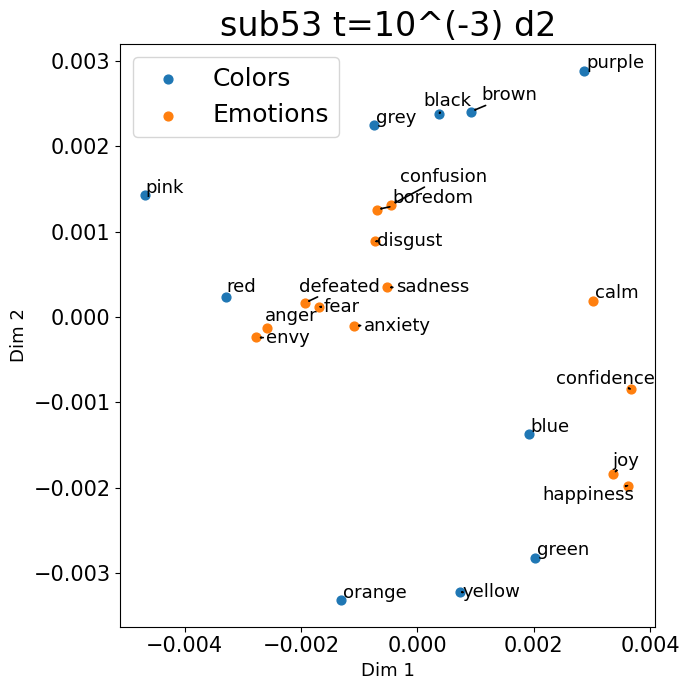

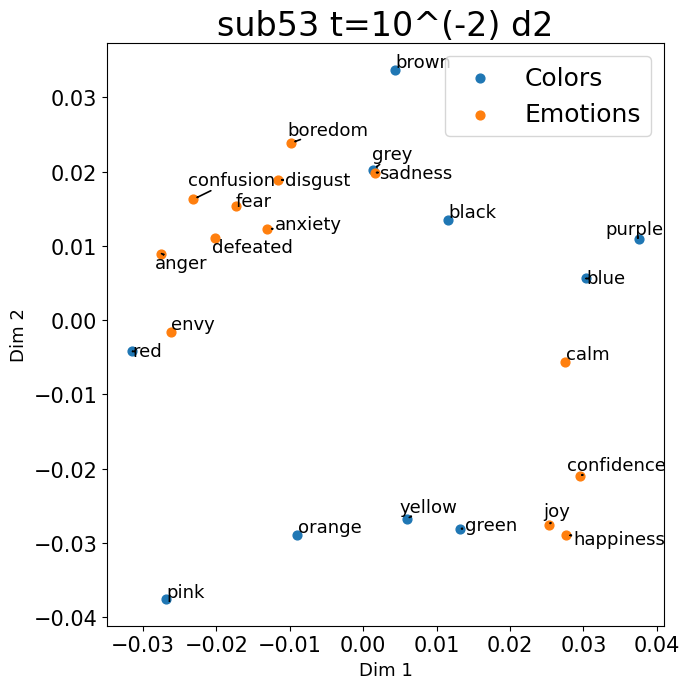

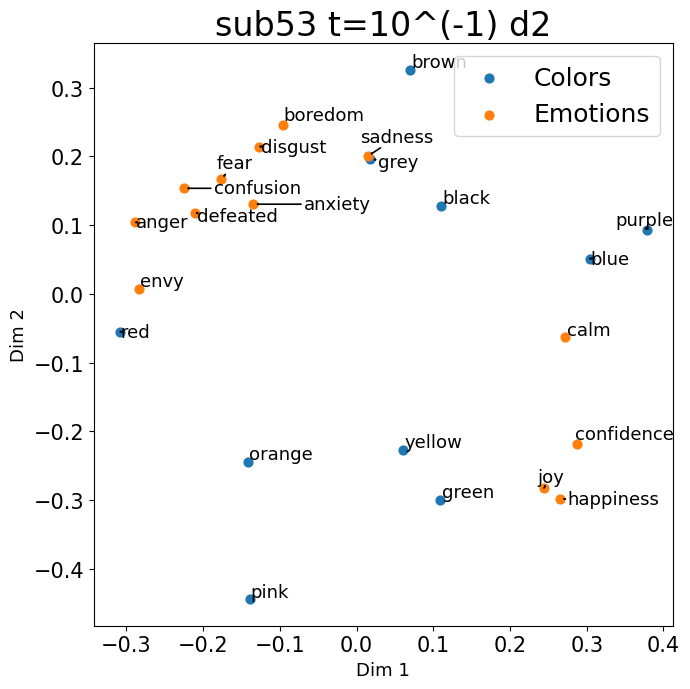

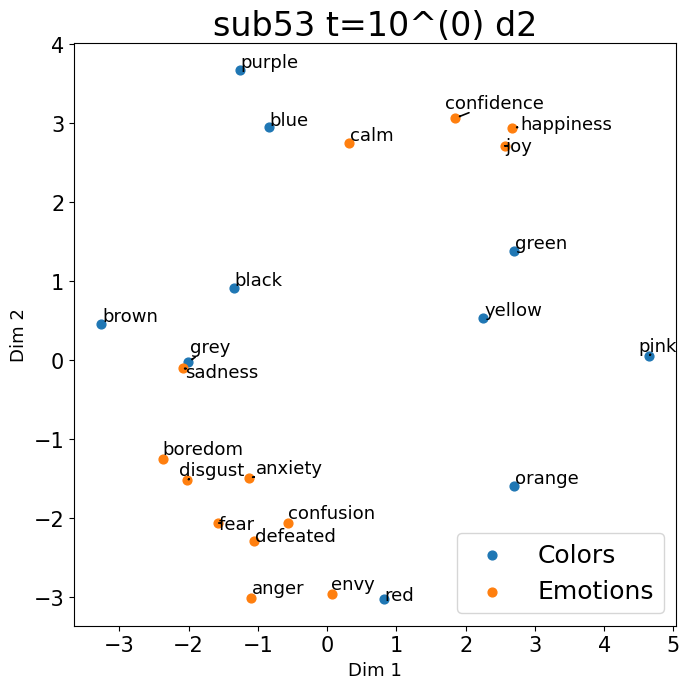

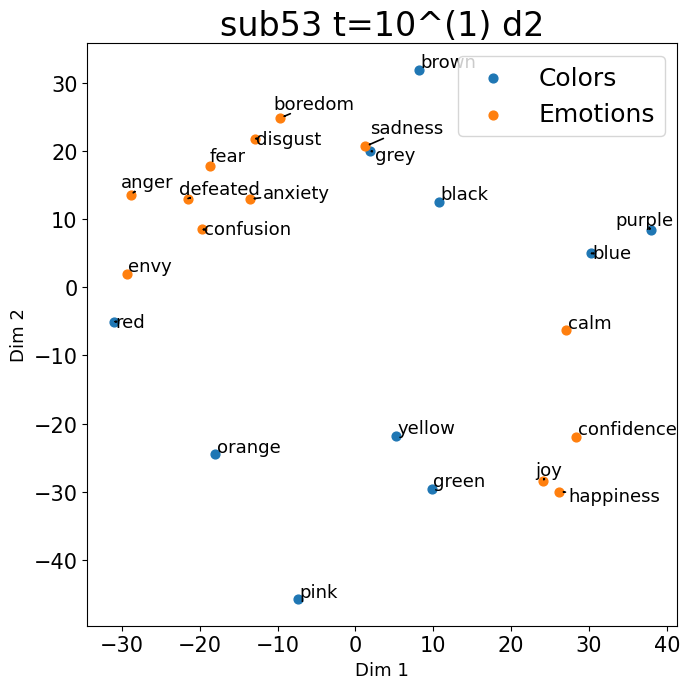

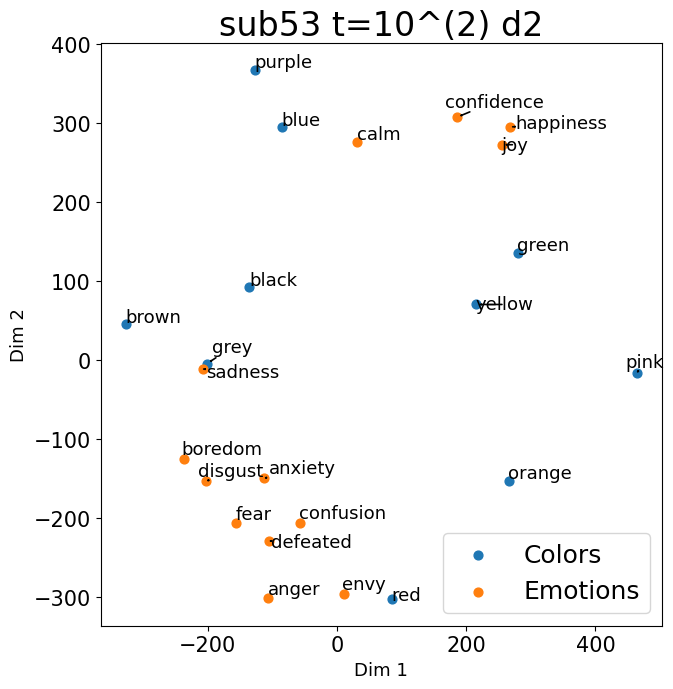

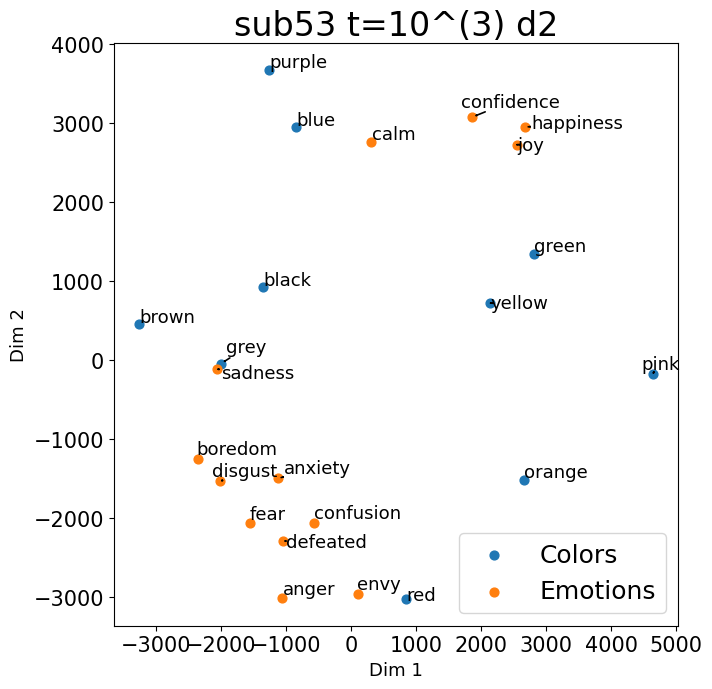

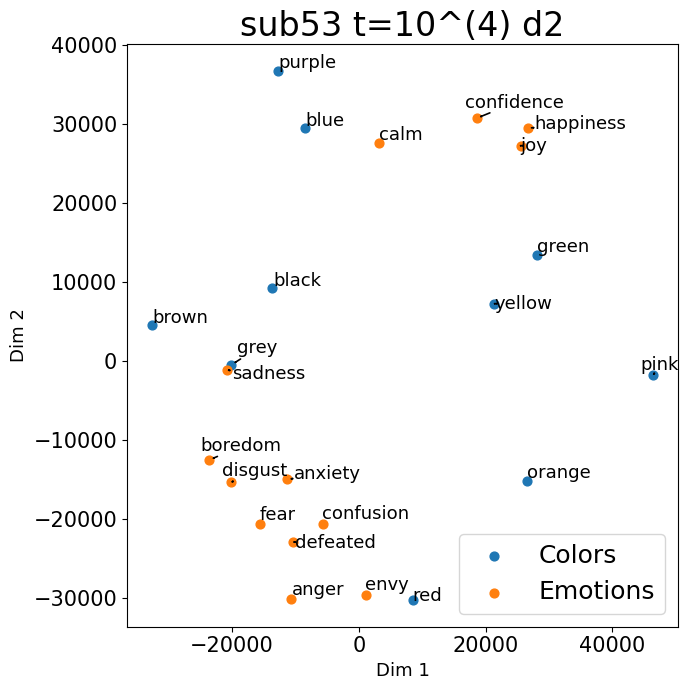

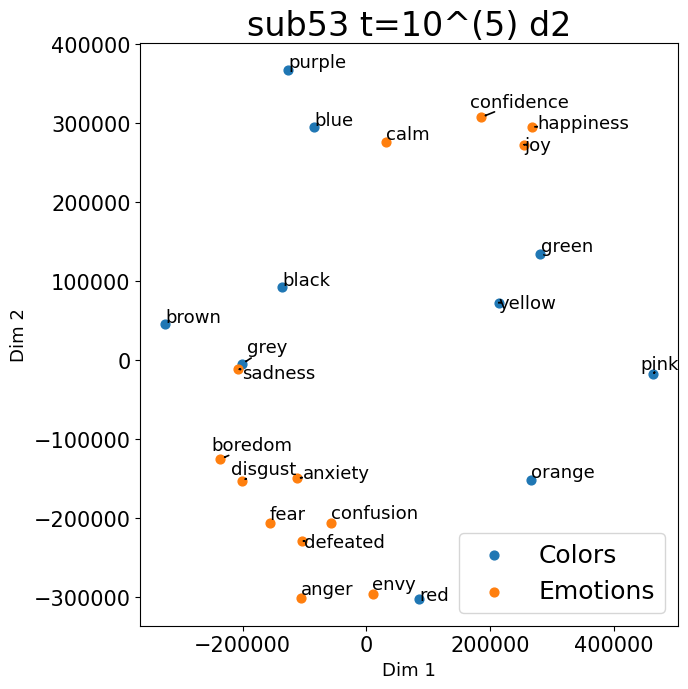

In [18]:
# visualization
for i_sub, sub in enumerate(subs):
    for i, t in enumerate(t_power):
        viz.plt_mds(mds_res_mean_dim2[i_sub, i], dissim_dfs[i_sub], save_path=figpath+f"/sub{sub} t=10^({t}) d2")
        #viz.plt_mds(mds_res_mean_dim3[i_sub, i], dissim_dfs[i_sub], save_path=figpath+f"/sub{sub} t=10^({t}) d3")